# Purpose: Revenue Quality & Profitability Analysis using Python (Business-Focused)
# Input: CSV file
# Output: Summary tables + charts

## Problem Statement

The objective of this analysis is to evaluate the quality of revenue and overall profitability of the business by identifying key drivers of profit, areas of inefficiency, and factors impacting margin performance.

While the business demonstrates strong sales growth, it is essential to understand whether this growth is translating into sustainable profitability. This analysis focuses on uncovering gaps between revenue and profit across categories, segments, regions, products, and customers.

Additionally, the study aims to identify the impact of pricing strategies, discounting behavior, and product mix on profitability, along with evaluating stability and consistency of performance over time.

The goal is to provide actionable insights that help improve margin efficiency, reduce loss-making transactions, and enable more profitable and stable business growth.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Ingestion

In [2]:
df= pd.read_csv('superstore_cleaned.csv')

In [3]:
print('Shape:', df.shape)
df.head()

Shape: (9993, 21)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,Hon Deluxe Fabric Upholstered Stacking Chairs-...,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning & Transformation

In [4]:
df['order_date']= pd.to_datetime(df['order_date'])
df['ship_date']= pd.to_datetime(df['ship_date'])

In [5]:
df.dtypes

row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code               int64
region                   object
product_id               object
category                 object
sub-category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object

## KPI Creation

In [6]:
df['profit_margin']= df['profit'] / df['sales'].replace(0,1)

In [7]:
df[['sales', 'profit', 'profit_margin']].head()

,sales,profit,profit_margin
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


### KPI Creation Insight:

- Profit margin has been calculated to evaluate business efficiency.
- This helps identify not just high sales, but profitable performance.
- Profit margin represents average transaction level performance and may differ from overall profitability, which is reflected by total profit.

## State-wise Analysis

In [8]:
state_summary= df.groupby('state').agg({
        'sales': 'sum',
        'profit': 'sum',
        'profit_margin': 'mean'
}).sort_values('sales', ascending= False)
state_summary

,sales,profit,profit_margin
state,,,
California,457687.6315,76381.3871,0.278334
New York,310876.2710,74038.5486,0.298366
Texas,170188.0458,-25729.3563,-0.342011
Washington,138641.2700,33402.6517,0.276354
Pennsylvania,116511.9140,-15559.9603,-0.086013
Florida,89473.7080,-3399.3017,-0.017953
Illinois,80166.1010,-12607.8870,-0.391677
Ohio,77976.7640,-16959.3178,-0.073874
Michigan,76269.6140,24463.1876,0.333390


### State-wise Insights:

- California and New York generate the highest sales and profit.
- Texas and Illinois show negative profit despite high sales → potential pricing or cost issues.
- Michigan and Virginia have strong profit margins, indicating efficient operations.

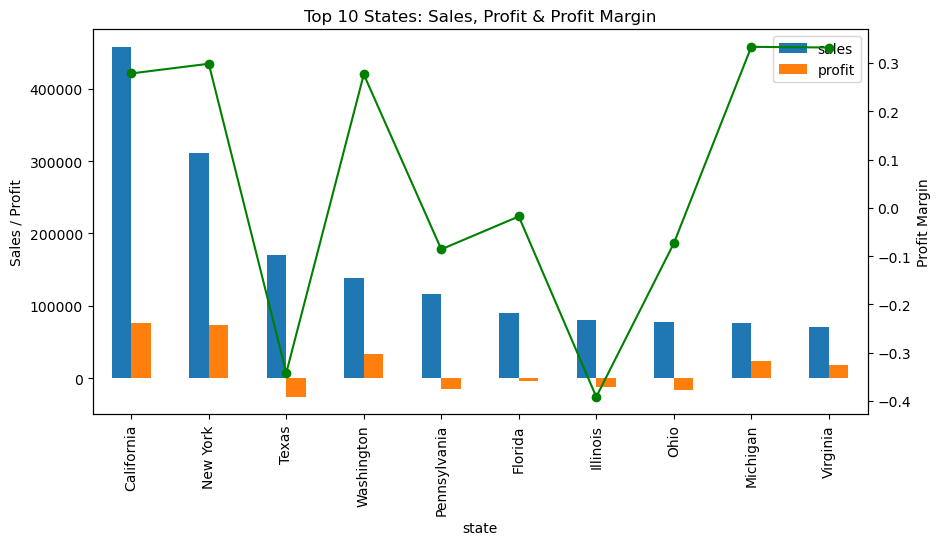

In [9]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Bar chart (sales & profit)
state_summary[['sales', 'profit']].head(10).plot(
    kind='bar', ax=ax1
)

# Line chart (profit margin)
ax2= ax1.twinx()
state_summary['profit_margin'].head(10).plot(
    color='green', marker= 'o', ax=ax2
)

# Titles
ax1.set_title('Top 10 States: Sales, Profit & Profit Margin')
ax1.set_ylabel('Sales / Profit')
ax2.set_ylabel('Profit Margin')

plt.show()

### Visualization Insight:

- The gap between sales and profit is clearly visible across states.
- Loss-making states are easily identifiable through negative profit bars.
- Profit margin trend highlights efficiency differences across regions.
- Pennsylvania, Florida, and Ohio exhibit negative total profit despite moderate average profit margins, suggesting inconsistent transaction-level performance with a few high-loss orders outweighing several profitable ones.

## Category-wise Analysis

In [10]:
category_summary= df.groupby('category').agg({
    'sales': 'sum',
    'profit': 'sum'
}).sort_values('sales', ascending= False)

category_summary['profit_margin'] = (
    category_summary['profit'] / category_summary['sales']
)
category_summary.round(2)

,sales,profit,profit_margin
category,,,
Technology,836154.03,145454.95,0.17
Furniture,741718.42,18463.33,0.02
Office Supplies,719047.03,122490.80,0.17


### Category-wise Insights:

- Technology is the top-performing category with the highest sales and profit, along with a strong profit margin (~17%), making it the most efficient segment.
- Office Supplies shows balanced performance with solid profit and a healthy profit margin (~17%), indicating consistent and stable operations.
- Furniture generates substantial sales comparable to other categories but has a significantly lower profit margin (~2.5%), indicating cost inefficiencies or heavy discounting.
- Despite high revenue, Furniture contributes relatively low profit, making it the weakest category in terms of profitability.
- Unlike state-level analysis where average transaction-level margins were used, category-level margins reflect overall profitability using aggregated totals.

## Deep Business Analysis — Contribution

### Category Contribution — Revenue vs Profit Distribution

In [11]:
cat_summary= df.groupby('category').agg({
    'sales' : 'sum',
    'profit' : 'sum'
}).reset_index()

total_sales= cat_summary['sales'].sum()
total_profit= cat_summary['profit'].sum()

cat_summary['sales_contribution_%']= (cat_summary['sales']/ total_sales) * 100
cat_summary['profit_contribution_%']= (cat_summary['profit']/ total_profit) * 100

cat_summary['profit_margin']= cat_summary['profit'] / cat_summary['sales']

cat_summary= cat_summary.sort_values('profit_contribution_%', ascending= False)
cat_summary.round(2)

,category,sales,profit,sales_contribution_%,profit_contribution_%,profit_margin
2,Technology,836154.03,145454.95,36.40,50.79,0.17
1,Office Supplies,719047.03,122490.80,31.30,42.77,0.17
0,Furniture,741718.42,18463.33,32.29,6.45,0.02


### 🔍 Category Contribution Insights

- Technology contributes ~36% of total revenue but generates over 50% of total profit, indicating strong pricing power and a highly efficient cost structure. It acts as the primary profit engine of the business.
- Office Supplies contributes ~31% of revenue but delivers ~43% of total profit, showing a positive contribution gap and consistent efficiency. This category represents a stable and scalable profit driver.
- Furniture contributes ~32% of total revenue but only ~6% of profit, revealing a severe negative contribution gap. Despite being a major revenue contributor, it fails to translate sales into profit, indicating structural margin issues.
- The sharp contrast between Furniture and the other two categories suggests that profitability is not driven by revenue volume alone, but by cost control and pricing strategy.
- Overall, the business is heavily dependent on Technology and Office Supplies for profitability, while Furniture is diluting overall margins and requires immediate strategic attention.
- Improving Furniture’s margin even marginally could significantly increase overall business profitability due to its high revenue share.

### Segment Contribution — Customer Type Performance

In [12]:
seg_summary= df.groupby('segment').agg({
    'sales' : 'sum',
    'profit' : 'sum'
}).reset_index()

seg_summary['sales_%']= seg_summary['sales']/ seg_summary['sales'].sum() *100
seg_summary['profit_%']= seg_summary['profit']/ seg_summary['profit'].sum() *100

seg_summary['margin']= seg_summary['profit']/ seg_summary['sales']

seg_summary= seg_summary.sort_values('profit_%', ascending= False)
seg_summary.round(2)

,segment,sales,profit,sales_%,profit_%,margin
0,Consumer,1161401.34,134119.21,50.56,46.83,0.12
1,Corporate,706146.37,91979.13,30.74,32.11,0.13
2,Home Office,429371.78,60310.74,18.69,21.06,0.14


### 🔍 Segment Insights — Customer Profitability & Efficiency

- Consumer segment contributes the highest share of revenue (50.6%) but a relatively lower share of profit (46.8%), indicating slight margin pressure despite being the primary customer base.
- Corporate segment shows a balanced contribution, with 30.7% of revenue and 32.1% of profit, suggesting stable and efficient performance with no major profitability concerns.
- Home Office, while contributing the lowest revenue (18.69%), delivers a higher proportion of profit (21.06%) and the highest profit margin (~14%), making it the most efficient customer segment.
- The contrast between Consumer and Home Office segments indicates that higher sales volume does not necessarily translate into higher profitability, highlighting the importance of customer mix and pricing strategy.
- Overall, the business is volume-driven by Consumer customers but profitability is relatively stronger in smaller segments like Home Office, indicating potential for targeted growth strategies.

### Region Contribution — Geographic Performance

In [13]:
region_summary= df.groupby('region').agg({
    'sales' : 'sum',
    'profit' : 'sum'
}).reset_index()

region_summary['sales_%']= region_summary['sales'] / region_summary['sales'].sum()* 100
region_summary['profit_%']= region_summary['profit'] / region_summary['profit'].sum()* 100

region_summary['margin']= region_summary['profit'] / region_summary['sales']

region_summary= region_summary.sort_values("profit_%", ascending=False).round(2)
region_summary

,region,sales,profit,sales_%,profit_%,margin
3,West,725457.82,108418.45,31.58,37.85,0.15
1,East,678499.87,91534.84,29.54,31.96,0.13
2,South,391721.90,46749.43,17.05,16.32,0.12
0,Central,501239.89,39706.36,21.82,13.86,0.08


### 🔍 Region Insights — Geographic Performance

- West region is the strongest performer, contributing 31.6% of revenue and 37.9% of total profit, along with the highest profit margin (~15%), indicating a highly efficient and well-optimized market.
- East region shows balanced performance with 29.5% of revenue and 32.0% of profit, supported by a solid margin (~13%), making it a stable and reliable contributor.
- South region maintains proportional contribution between sales (17.0%) and profit (16.3%), indicating consistent but moderate performance without significant efficiency concerns.
- Central region contributes 21.8% of revenue but only 13.9% of profit, with the lowest margin (8%), highlighting a significant efficiency gap and potential cost or pricing issues.
- The disparity between West and Central regions suggests that geographic factors such as pricing strategy, logistics cost, or discounting policies may be impacting profitability unevenly across regions.

### 🚨 Business Problem Identification — Contribution Gap Analysis

In [14]:
cat_summary['gap']= cat_summary['sales_contribution_%']- cat_summary['profit_contribution_%']

cat_summary= cat_summary.sort_values('gap', ascending= False).round(2)
cat_summary

,category,sales,profit,sales_contribution_%,profit_contribution_%,profit_margin,gap
0,Furniture,741718.42,18463.33,32.29,6.45,0.02,25.85
1,Office Supplies,719047.03,122490.80,31.30,42.77,0.17,-11.46
2,Technology,836154.03,145454.95,36.40,50.79,0.17,-14.38


### 🚨 Category Gap Analysis — Business Problem Identification

- Furniture shows a significant positive gap (+25.9%), contributing 32.3% of total revenue but only 6.5% of profit, clearly indicating severe inefficiency. Despite strong sales, it fails to convert revenue into profit, suggesting structural issues such as heavy discounting or high operational costs.
- Technology has a negative gap (-14.4%), generating 36.4% of revenue but over 50.8% of total profit, making it the most efficient and dominant profit driver with strong pricing power and cost control.
- Office Supplies also demonstrates a negative gap (-11.5%), contributing 31.3% of revenue and 42.8% of profit, indicating a well-balanced and consistently profitable category.
- The stark contrast between Furniture and the other two categories highlights that profitability is heavily concentrated in Technology and Office Supplies, while Furniture is diluting overall business margins.
- The business is not facing a revenue problem but a margin distribution problem, where one major category (Furniture) is underperforming despite significant sales contribution.
- Addressing margin inefficiencies in Furniture could unlock substantial profit improvement, as even small margin gains on its high revenue base would significantly impact overall profitability.

### 🔍 Deep Dive — Furniture (Loss Driver Analysis)

In [15]:
furniture_df = df[df['category'] == 'Furniture']

In [16]:
subcat_summary= furniture_df.groupby('sub-category').agg({
    'sales' : 'sum',
    'profit' : 'sum'
}).reset_index()

subcat_summary['profit_margin']= subcat_summary['profit'] / subcat_summary['sales']

subcat_summary= subcat_summary.sort_values('profit', ascending= True).round(2)

subcat_summary

,sub-category,sales,profit,profit_margin
3,Tables,206965.53,-17725.48,-0.09
0,Bookcases,114880.00,-3472.56,-0.03
2,Furnishings,91705.16,13059.14,0.14
1,Chairs,328167.73,26602.23,0.08


### 🔍 Furniture Deep Dive — Root Cause of Low Profitability

- Tables are the biggest loss driver, generating 206K in sales but incurring a loss of 17.7K with a negative margin (-9%). This indicates severe pricing or discounting issues, making it the primary reason behind Furniture’s overall poor performance.
- Bookcases also contribute negatively to profit (3.4K loss) despite moderate sales (115K), reinforcing that losses in Furniture are not isolated but concentrated in specific subcategories.
- Chairs, while being the highest revenue contributor (328K), generate only 26.6K profit with a relatively low margin (8%), suggesting that even high-volume products within Furniture are not efficiently priced.
- Furnishings is the only strong performer with a healthy margin (14%), but its relatively lower sales volume (91K) limits its ability to offset losses from Tables and Bookcases.
- The overall inefficiency of the Furniture category is driven by a combination of loss-making subcategories (Tables, Bookcases) and low-margin high-volume products (Chairs), rather than a uniform issue across all products.
- Further analysis of discount impact within the Furniture category is required to validate whether aggressive discounting is the primary driver of losses, particularly in Tables and Bookcases.

### 🔍 Discount Impact Analysis — Furniture Category

In [17]:
discount_subcat_summary= furniture_df.groupby('sub-category').agg({
    'sales' : 'sum',
    'profit' : 'sum',
    'discount' : 'mean'
}).reset_index()

discount_subcat_summary['profit_margin']= discount_subcat_summary['profit'] / discount_subcat_summary['sales']

discount_subcat_summary= discount_subcat_summary.sort_values('discount', ascending= False).round(2)

discount_subcat_summary

,sub-category,sales,profit,discount,profit_margin
3,Tables,206965.53,-17725.48,0.26,-0.09
0,Bookcases,114880.00,-3472.56,0.21,-0.03
1,Chairs,328167.73,26602.23,0.17,0.08
2,Furnishings,91705.16,13059.14,0.14,0.14


### 🔍 Discount Impact Insights — Furniture Category

- Tables have the highest average discount (26%) and are also the most loss-making subcategory (margin -9%), clearly indicating that aggressive discounting is directly eroding profitability.
- Bookcases follow a similar pattern, with relatively high discounts (21%) and negative profit margins (-3%), reinforcing that discounting is a consistent driver of losses within Furniture.
- Chairs operate at a moderate discount level (17%) and generate positive but relatively low margins (8%), suggesting that even controlled discounting limits profitability in high-volume products.
- Furnishings has the lowest average discount (14%) and the highest profit margin (14%), indicating strong pricing discipline and efficient cost management.
- A clear inverse relationship is observed between discount levels and profit margins across subcategories, confirming that excessive discounting—not lack of demand—is the primary driver of poor performance in the Furniture category.
- Optimizing discount strategies in Tables and Bookcases could materially improve margins and elevate the Furniture category’s performance, which currently generates substantial revenue but operates at a thin overall margin (~2%).

## Time-based Trends

In [18]:
df_time = df.set_index('order_date')

In [19]:
monthly_data = df_time[['sales' , 'profit']].resample('ME').sum()

In [20]:
monthly_data.head()

,sales,profit
order_date,,
2014-01-31,14236.895,2450.1907
2014-02-28,4519.892,862.3084
2014-03-31,55691.009,498.7299
2014-04-30,28013.973,3500.8940
2014-05-31,23648.287,2738.7096


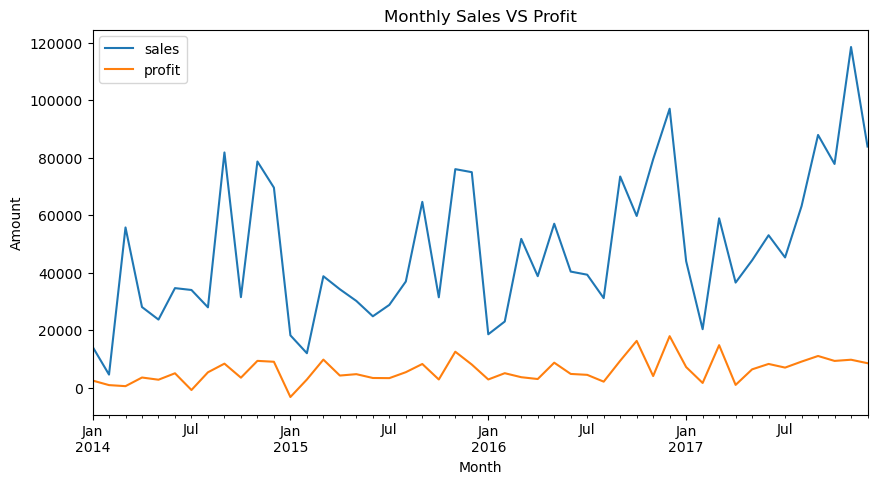

In [21]:
monthly_data.plot(figsize=(10,5))
plt.title('Monthly Sales VS Profit')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.show()

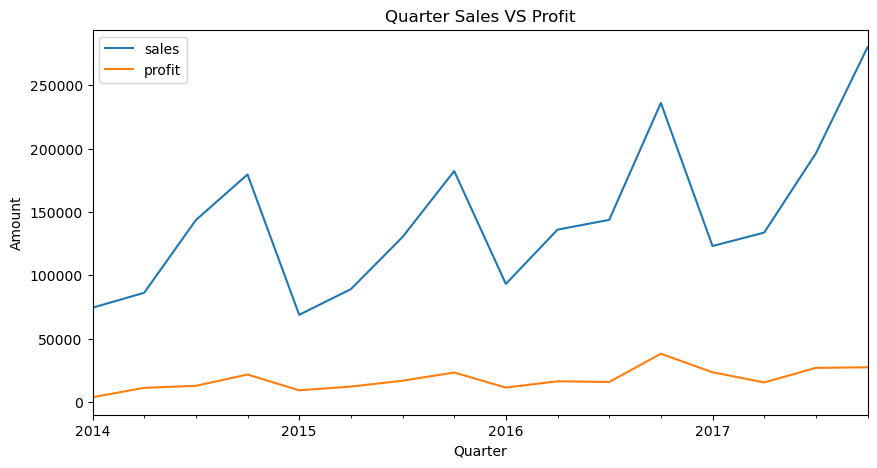

In [22]:
quarterly_data = df_time[['sales' , 'profit']].resample('QE').sum()

quarterly_data.plot(figsize=(10,5))
plt.title('Quarter Sales VS Profit')
plt.xlabel('Quarter')
plt.ylabel('Amount')
plt.show()

### Time-Based Sales & Profit Insights:

- Sales and profit show a consistent upward trend over time, indicating steady business growth and expanding market performance across years.
- Monthly data highlights short-term volatility, while quarterly aggregation smooths fluctuations and confirms a strong underlying growth trajectory.
- A clear seasonal pattern is observed, with Q4 (October–December) consistently delivering peak sales and profit, likely driven by festive seasons, year-end demand, and promotional activities.
- Q1 (January–March) tends to underperform relative to other quarters, suggesting a post-holiday slowdown and potential demand drop at the beginning of the year.
- Sales and profit move closely together, indicating that revenue growth is largely translating into profitability; however, variability in profit suggests margin sensitivity.
- Occasional monthly dips in profit despite stable sales indicate potential cost pressures, discounting strategies, or inefficient operations during certain periods.

### Recommendations:

- Leverage Q4 strength by increasing inventory, marketing spend, and targeted promotions to maximize revenue during peak demand periods.
- Improve Q1 performance through strategic initiatives such as early-year discounts, new product launches, or customer retention campaigns to reduce seasonal slowdown.
- Investigate months with profit dips to identify causes such as high discounts, increased costs, or low-margin product mix, and optimize pricing or cost structures accordingly.
- Focus on maintaining consistent profit margins by controlling operational costs and avoiding excessive discounting during non-peak periods.
- Use quarterly trends for strategic planning and monthly trends for operational monitoring and timely interventions.

## 📈 Variance Analysis — Quarterly Business Performance

In [23]:
quarterly = df.set_index('order_date').resample('QE').agg({
    'sales' : 'sum',
    'profit' : 'sum'
})

quarterly.round(2)

,sales,profit
order_date,,
2014-03-31,74447.80,3811.23
2014-06-30,86257.39,11216.13
2014-09-30,143633.21,12804.72
2014-12-31,179627.73,21723.95
2015-03-31,68851.74,9264.94
2015-06-30,89124.19,12190.92
2015-09-30,130259.58,16853.62
2015-12-31,182297.01,23309.12
2016-03-31,93237.18,11441.37


In [24]:
quarterly['sales_change_%']= quarterly['sales'].pct_change()*100
quarterly['profit_change_%']= quarterly['profit'].pct_change()*100

quarterly.round(2)

,sales,profit,sales_change_%,profit_change_%
order_date,,,,
2014-03-31,74447.80,3811.23,NaN,NaN
2014-06-30,86257.39,11216.13,15.86,194.29
2014-09-30,143633.21,12804.72,66.52,14.16
2014-12-31,179627.73,21723.95,25.06,69.66
2015-03-31,68851.74,9264.94,-61.67,-57.35
2015-06-30,89124.19,12190.92,29.44,31.58
2015-09-30,130259.58,16853.62,46.16,38.25
2015-12-31,182297.01,23309.12,39.95,38.30
2016-03-31,93237.18,11441.37,-48.85,-50.91


In [25]:
quarterly['profit_margin']= quarterly['profit'] / quarterly['sales']
quarterly['margin_change']= quarterly['profit_margin'].diff()

quarterly.round(2)

,sales,profit,sales_change_%,profit_change_%,profit_margin,margin_change
order_date,,,,,,
2014-03-31,74447.80,3811.23,NaN,NaN,0.05,NaN
2014-06-30,86257.39,11216.13,15.86,194.29,0.13,0.08
2014-09-30,143633.21,12804.72,66.52,14.16,0.09,-0.04
2014-12-31,179627.73,21723.95,25.06,69.66,0.12,0.03
2015-03-31,68851.74,9264.94,-61.67,-57.35,0.13,0.01
2015-06-30,89124.19,12190.92,29.44,31.58,0.14,0.00
2015-09-30,130259.58,16853.62,46.16,38.25,0.13,-0.01
2015-12-31,182297.01,23309.12,39.95,38.30,0.13,-0.00
2016-03-31,93237.18,11441.37,-48.85,-50.91,0.12,-0.01


In [26]:
def detect_issue(row):
    if row['sales_change_%'] >0 and row['profit_change_%'] <0:
        return 'Sales Up, Profit Down'
    elif row['profit_change_%'] < -20:
        return 'Profit drop'
    elif row['sales_change_%'] > 30:
        return 'Growth Spike'
    else:
        return 'Normal'

quarterly['alert']= quarterly.apply(detect_issue, axis=1)

quarterly.round(2)

,sales,profit,sales_change_%,profit_change_%,profit_margin,margin_change,alert
order_date,,,,,,,
2014-03-31,74447.80,3811.23,NaN,NaN,0.05,NaN,Normal
2014-06-30,86257.39,11216.13,15.86,194.29,0.13,0.08,Normal
2014-09-30,143633.21,12804.72,66.52,14.16,0.09,-0.04,Growth Spike
2014-12-31,179627.73,21723.95,25.06,69.66,0.12,0.03,Normal
2015-03-31,68851.74,9264.94,-61.67,-57.35,0.13,0.01,Profit drop
2015-06-30,89124.19,12190.92,29.44,31.58,0.14,0.00,Normal
2015-09-30,130259.58,16853.62,46.16,38.25,0.13,-0.01,Growth Spike
2015-12-31,182297.01,23309.12,39.95,38.30,0.13,-0.00,Growth Spike
2016-03-31,93237.18,11441.37,-48.85,-50.91,0.12,-0.01,Profit drop


### 🔍 Variance Insights — Quarterly Business Performance

- Strong and recurring growth spikes are observed in Q3 and Q4 across multiple years (2014, 2015, 2016, 2017), indicating consistent seasonal demand and successful year-end sales cycles.
- Q1 (March quarters) consistently shows sharp declines in both sales and profit (e.g., 2015, 2016, 2017), highlighting a recurring post-peak slowdown and demand contraction after the high-performing Q4 period.
- Instances of “Sales Up, Profit Down” (e.g., Sep 2016, Jun 2017) indicate margin pressure, where revenue growth is not translating into profitability, likely due to increased discounting or unfavorable product mix.
- Profit drops in multiple Q1 periods (2015, 2016, 2017) suggest structural seasonality rather than isolated events, indicating predictable business cycles.
- While revenue shows strong growth patterns, profit growth is more volatile, and margin fluctuations (e.g., drop in Jun 2017 and Dec 2017) highlight sensitivity to pricing and cost control.
- The business demonstrates strong recovery patterns after weak quarters, particularly moving from Q1 declines to Q2/Q3 growth, indicating resilience and demand rebound capability.

### 💡 Recommendations — Strategic Actions

- Capitalize on Q3–Q4 peaks by aligning inventory, marketing, and promotions with high-demand periods.  
- Mitigate recurring Q1 slowdowns through early-year campaigns, retention efforts, and targeted product launches.  
- Analyze “Sales Up, Profit Down” periods to optimize pricing, discounting, and product mix.  
- Improve margin consistency by controlling discounts and enhancing cost efficiency.  
- Align planning with seasonal patterns and use variance tracking for timely corrective actions.  
- Prioritize high-margin categories during growth phases to ensure revenue translates into profitability.

The business is not facing a demand problem but a seasonality and margin optimization challenge, where aligning pricing and cost strategies with demand cycles can significantly improve profitability.

### 📊 Stability Analysis — Profit Consistency by Segment

In [27]:
segment_trend= df.groupby(['segment', pd.Grouper(key= 'order_date', freq= 'ME')]
                         )['profit'].sum().reset_index()

In [28]:
volatility = segment_trend.groupby('segment')['profit'].std().reset_index()

volatility.columns = ['segment', 'profit_volatility']

volatility.sort_values('profit_volatility', ascending= False)

,segment,profit_volatility
0,Consumer,2824.340479
1,Corporate,1950.919071
2,Home Office,1378.025105


### 🔍 Stability Insights — Segment Performance Consistency

- Consumer segment shows the highest profit volatility, indicating that while it drives the majority of revenue, its performance is less predictable and more sensitive to fluctuations, making it a less reliable profit contributor.
- Corporate segment demonstrates moderate volatility, suggesting a balance between growth and stability, aligning with its earlier classification as a consistent and stable performer.
- Home Office exhibits the lowest volatility, reinforcing its position as the most efficient and reliable segment, with consistent profit generation despite lower overall sales contribution.
- The contrast between Consumer and Home Office segments highlights a key trade-off between scale and stability — high-revenue segments tend to be more volatile, while smaller segments offer more predictable performance.
- Overall, the business relies heavily on the Consumer segment for revenue growth, but long-term stability and profitability are better supported by segments like Home Office, indicating the importance of balancing volume with consistency in customer strategy.

### ⚠️ Anomaly Analysis — Loss Drivers & Extreme Cases

In [29]:
high_discount= df[df['discount'] > 0.5]

high_discount.sort_values('discount', ascending= False).head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,profit_margin
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.810,5,0.8,-123.8580,-1.80
8073,8075,CA-2017-151750,2017-01-01,2017-01-05,Standard Class,JM-15250,Janet Martin,Consumer,United States,Huntsville,...,Central,OFF-BI-10000343,Office Supplies,Binders,"Pressboard Covers with Storage Hooks- 9 1/2"" x...",13.748,14,0.8,-22.6842,-1.65
2826,2827,US-2014-112914,2014-09-25,2014-09-30,Standard Class,MT-18070,Michelle Tran,Home Office,United States,Houston,...,Central,OFF-BI-10002982,Office Supplies,Binders,Avery Self-Adhesive Photo Pockets for Polaroid...,2.724,2,0.8,-4.3584,-1.60
8020,8022,CA-2014-129189,2014-07-21,2014-07-25,Standard Class,HM-14860,Harry Marie,Corporate,United States,Dallas,...,Central,OFF-AP-10000124,Office Supplies,Appliances,Acco 6 Outlet Guardian Basic Surge Suppressor,4.992,3,0.8,-12.9792,-2.60
8023,8025,CA-2014-129189,2014-07-21,2014-07-25,Standard Class,HM-14860,Harry Marie,Corporate,United States,Dallas,...,Central,OFF-BI-10000494,Office Supplies,Binders,Acco Economy Flexible Poly Round Ring Binder,1.044,1,0.8,-1.8270,-1.75


In [30]:
loss_df= df[df['profit'] < 0]

loss_df.sort_values('profit').head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,profit_margin
7771,7773,CA-2016-108196,2016-11-25,2016-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780,-1.466667
683,684,US-2017-168116,2017-11-04,2017-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,-0.480000
9773,9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,-1.700000
3011,3012,CA-2017-134845,2017-04-17,2017-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,West,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800,-1.333333
4990,4992,US-2017-122714,2017-12-07,2017-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845,-1.550000


In [31]:
loss_by_category = loss_df.groupby('category')['profit'].count()
loss_by_category.reset_index()

,category,profit
0,Furniture,713
1,Office Supplies,886
2,Technology,271


In [32]:
loss_by_discount = loss_df.groupby('discount')['profit'].count()
loss_by_discount.reset_index()

,discount,profit
0,0.10,4
1,0.15,17
2,0.20,502
3,0.30,207
4,0.32,27
5,0.40,180
6,0.45,11
7,0.50,66
8,0.60,138
9,0.70,418


In [33]:
high_discount_loss = high_discount[high_discount['profit']<0]

high_discount_loss_count= high_discount_loss.shape[0]
total_high_discount= high_discount.shape[0]

high_discount_loss_count, total_high_discount

(856, 856)

In [34]:
high_discount.groupby('category')['profit'].count()

category
Furniture          153
Office Supplies    680
Technology          23
Name: profit, dtype: int64

### 🔍 Anomaly Insights — Loss Drivers & Discount Impact

- All high-discount transactions (>50%) result in losses (856 out of 856), confirming that extreme discounting is inherently unsustainable and directly leads to negative profitability.
- Losses are concentrated at higher discount levels, particularly around 0.20, 0.70, and 0.80, indicating a strong relationship between increasing discount levels and rising likelihood of loss.
- Loss-making transactions are observed across all categories, with Office Supplies having the highest count, followed by Furniture and Technology, indicating that discount-driven losses are a widespread issue rather than category-specific.
- However, when combined with earlier contribution and margin analysis, it becomes clear that the impact of these losses is most severe in Furniture, where already low margins make the category highly sensitive to discounting.
- This aligns with subcategory-level findings, where higher discount levels in Tables and Bookcases directly correspond to negative or weak margins, confirming that discounting is a key structural driver of inefficiency in Furniture.
- Overall, the business’s profitability challenge is not demand-driven but pricing-driven, where excessive discounting—especially in low-margin categories—erodes profitability at the transaction level.

### 💡 Recommendations — Stability & Profit Optimization

- Reduce dependency on the Consumer segment by strengthening focus on more stable segments like Home Office, which offer consistent and higher-quality profit streams.
- Maintain Corporate as a balanced segment while optimizing its growth to support both revenue expansion and earnings stability.
- Implement strict discount controls, especially eliminating extreme discount levels (>50%), as they consistently lead to losses and erode overall profitability.
- Introduce category-specific discount thresholds, with tighter controls on low-margin categories like Furniture to prevent margin dilution.
- Re-evaluate pricing and discount strategies for subcategories such as Tables and Bookcases, where aggressive discounting is directly driving losses.
- Shift focus from volume-driven sales to margin-driven growth by prioritizing high-margin and low-volatility segments and products.
- Establish monitoring mechanisms to track loss-making transactions and high-risk discount levels, enabling early intervention and better pricing discipline.

### 📈 Trend Smoothing — Rolling Average Analysis

In [35]:
monthly= df.set_index('order_date').resample('ME').agg({
    'sales' : 'sum',
    'profit' : 'sum'
})

monthly['sales_rolling_3']= monthly['sales'].rolling(window=3).mean()
monthly['profit_rolling_3']= monthly['profit'].rolling(window=3).mean()

monthly.round(2)

,sales,profit,sales_rolling_3,profit_rolling_3
order_date,,,,
2014-01-31,14236.90,2450.19,NaN,NaN
2014-02-28,4519.89,862.31,NaN,NaN
2014-03-31,55691.01,498.73,24815.93,1270.41
2014-04-30,28013.97,3500.89,29408.29,1620.64
2014-05-31,23648.29,2738.71,35784.42,2246.11
2014-06-30,34595.13,4976.52,28752.46,3738.71
2014-07-31,33946.39,-841.48,30729.94,2291.25
2014-08-31,27909.47,5318.10,32150.33,3151.05
2014-09-30,81777.35,8328.10,47877.74,4268.24


### 🔍 Trend Insights — Smoothed Sales & Profit Analysis

- The rolling average clearly shows a consistent upward trend in sales over time, confirming that the business is growing beyond short-term fluctuations and seasonal spikes.
- Profit also demonstrates an overall increasing trend; however, compared to sales, it shows more variability, indicating that revenue growth is not always translating into proportional profit growth.
- In early periods (2014–2015), both sales and profit rolling averages remain relatively low and unstable, reflecting an initial growth phase with inconsistent performance.
- From 2016 onwards, the rolling averages for both sales and profit increase significantly, indicating a more stable growth phase with improved business scale and performance.
- Despite overall growth, certain periods show divergence between sales and profit trends, suggesting margin pressure where increasing sales do not fully convert into profit, likely due to discounting or cost inefficiencies.
- The smoothing effect removes short-term noise and highlights that the underlying business trend is positive, but profitability improvement is less consistent than revenue growth.
- The business demonstrates strong revenue growth momentum, but improving the efficiency of converting sales into profit remains a key opportunity.

### 🔁 Lag Analysis — Month-over-Month Comparison

In [36]:
monthly['prev_sales']= monthly['sales'].shift(1)
monthly['prev_profit']= monthly['profit'].shift(1)

monthly['sales_change_%']= (monthly['sales']- monthly['prev_sales'])/ monthly['prev_sales']*100
monthly['profit_change_%']= (monthly['profit']- monthly['prev_profit'])/monthly['prev_profit']*100

monthly.round(2)

,sales,profit,sales_rolling_3,profit_rolling_3,prev_sales,prev_profit,sales_change_%,profit_change_%
order_date,,,,,,,,
2014-01-31,14236.90,2450.19,NaN,NaN,NaN,NaN,NaN,NaN
2014-02-28,4519.89,862.31,NaN,NaN,14236.90,2450.19,-68.25,-64.81
2014-03-31,55691.01,498.73,24815.93,1270.41,4519.89,862.31,1132.13,-42.16
2014-04-30,28013.97,3500.89,29408.29,1620.64,55691.01,498.73,-49.70,601.96
2014-05-31,23648.29,2738.71,35784.42,2246.11,28013.97,3500.89,-15.58,-21.77
2014-06-30,34595.13,4976.52,28752.46,3738.71,23648.29,2738.71,46.29,81.71
2014-07-31,33946.39,-841.48,30729.94,2291.25,34595.13,4976.52,-1.88,-116.91
2014-08-31,27909.47,5318.10,32150.33,3151.05,33946.39,-841.48,-17.78,-731.99
2014-09-30,81777.35,8328.10,47877.74,4268.24,27909.47,5318.10,193.01,56.60


### 🔍 Lag Insights — Short-Term Performance & Anomaly Detection

- The business shows significant month-to-month volatility, with frequent sharp fluctuations in both sales and profit, indicating sensitivity to short-term factors such as discounting, promotions, or demand shifts.
- Several instances of extreme divergence between sales and profit are observed. For example, periods where sales decline sharply but profit increases, or vice versa, indicate inconsistent margin behavior and unstable cost or pricing structures.
- Notable spikes in both sales and profit (e.g., March 2015, September 2016, March 2017) suggest strong demand surges or promotional impacts, but these are not always sustained in subsequent months, highlighting short-term growth rather than consistent expansion.
- Multiple instances of “profit dropping more sharply than sales” (e.g., early 2016 and mid-2017) indicate margin pressure, where cost increases or discounting strategies disproportionately affect profitability.
- Periods with extreme profit percentage changes (both positive and negative) highlight that profit is significantly more volatile than sales, reinforcing earlier findings that revenue growth is not consistently translating into stable profitability.
- The presence of sudden drops immediately following high-growth months suggests post-peak corrections, aligning with previously observed seasonality patterns (strong Q4 followed by weaker Q1 performance).
- Overall, the business demonstrates strong short-term growth potential but lacks consistency, with frequent performance swings indicating the need for better pricing discipline and cost control mechanisms.
- While the business demonstrates strong growth momentum, frequent short-term fluctuations highlight the need for improved operational stability and margin control.

### 💡 Recommendations — Trend Stability & Performance Consistency

- Focus on improving profit conversion efficiency by aligning pricing and cost strategies with revenue growth, ensuring that increasing sales consistently translate into higher profitability.
- Reduce short-term volatility by stabilizing discounting and promotional strategies, avoiding aggressive fluctuations that lead to unpredictable profit outcomes.
- Implement tighter cost and margin monitoring during high-growth periods to prevent profit erosion following sales spikes.
- Leverage strong growth phases by optimizing product mix and prioritizing high-margin offerings to sustain profitability beyond short-term demand surges.
- Develop strategies to smooth post-peak declines, particularly after high-performing periods, to maintain more consistent revenue and profit performance across months.

## Category in Loss

In [37]:
loss_category= df.groupby('category')['profit'].sum().sort_values()
loss_category

category
Furniture           18463.3316
Office Supplies    122490.8008
Technology         145454.9481
Name: profit, dtype: float64

### Loss Analysis Insight:

- No category is overall loss-making, as all categories have positive total profit.
- However, Furniture shows significantly lower profitability compared to others, indicating potential inefficiencies.

### 🏆 Ranking Analysis — Top & Bottom Performers

In [38]:
product_summary= df.groupby(['category', 'sub-category']).agg({
    'sales' : 'sum',
    'profit' : 'sum'
})

product_summary['profit_margin']= product_summary['profit'] / product_summary['sales']

# Bottom performers (profit)
worst_products =  product_summary.sort_values('profit').head(10)

worst_products.reset_index().round(2)

,category,sub-category,sales,profit,profit_margin
0,Furniture,Tables,206965.53,-17725.48,-0.09
1,Furniture,Bookcases,114880.00,-3472.56,-0.03
2,Office Supplies,Supplies,46673.54,-1189.10,-0.03
3,Office Supplies,Fasteners,3024.28,949.52,0.31
4,Technology,Machines,189238.63,3384.76,0.02
5,Office Supplies,Labels,12486.31,5546.25,0.44
6,Office Supplies,Art,27118.79,6527.79,0.24
7,Office Supplies,Envelopes,16476.40,6964.18,0.42
8,Furniture,Furnishings,91705.16,13059.14,0.14
9,Office Supplies,Appliances,107532.16,18138.01,0.17


In [39]:
# Bottom performers (profit margin)
worst_products =  product_summary.sort_values('profit_margin').head(10)

worst_products.reset_index().round(2)

,category,sub-category,sales,profit,profit_margin
0,Furniture,Tables,206965.53,-17725.48,-0.09
1,Furniture,Bookcases,114880.00,-3472.56,-0.03
2,Office Supplies,Supplies,46673.54,-1189.10,-0.03
3,Technology,Machines,189238.63,3384.76,0.02
4,Furniture,Chairs,328167.73,26602.23,0.08
5,Office Supplies,Storage,223843.61,21278.83,0.10
6,Technology,Phones,330007.05,44515.73,0.13
7,Furniture,Furnishings,91705.16,13059.14,0.14
8,Office Supplies,Binders,203412.73,30221.76,0.15
9,Office Supplies,Appliances,107532.16,18138.01,0.17


### 🔍 Ranking Insights — Sub-Category Profitability & Risk Drivers

- Tables and Bookcases (Furniture) are the weakest performers, generating significant revenue while incurring losses or negative margins, confirming that Furniture’s inefficiency is driven by structurally unprofitable subcategories rather than lack of demand.
- Supplies (Office Supplies) also shows negative profitability despite moderate sales, indicating that loss-making behavior exists across categories; however, its overall impact is limited due to stronger performance from other subcategories within the same category.
- Machines (Technology), despite high sales (~189K), operates at an extremely low profit margin (2%), suggesting that even within high-performing categories, certain subcategories suffer from pricing or cost inefficiencies.
- Chairs (Furniture), while being a high-revenue subcategory (~328K), delivers relatively low margins (8%), highlighting that even top-selling products within Furniture are not efficiently converting sales into profit.
- In contrast, subcategories such as Labels, Envelopes, and Art (Office Supplies) exhibit very high profit margins (20–44%), reflecting strong pricing power and cost efficiency, and acting as key profitability stabilizers for the category.
- Office Supplies presents a diversified profitability structure, where multiple subcategories generate moderate but consistently high-margin returns. This distributed model reduces dependency on any single product and allows the category to remain stable despite the presence of a few underperforming areas like Supplies.
- The contrast between loss-making and high-margin subcategories highlights that profitability is highly uneven at the product level, with overall performance driven by a small number of underperforming or overperforming subcategories.
- The business’s margin problem is therefore highly concentrated, where a few subcategories—primarily within Furniture—disproportionately drag down overall profitability, while others generate strong and stable returns.
- This reinforces earlier category-level insights: Furniture’s weakness is driven by product mix and pricing inefficiencies, whereas Technology and Office Supplies maintain profitability through a more efficient and balanced subcategory structure.

## Category + Region Analysis (by transactions)

In [40]:
loss_transactions= df[df['profit'] <0]\
    .groupby(['category' , 'region'])['profit']\
    .sum()\
    .reset_index()\
    .sort_values('profit')

loss_transactions

,category,region,profit
4,Office Supplies,Central,-33484.1655
9,Technology,East,-20997.6322
0,Furniture,Central,-19554.3653
1,Furniture,East,-18789.7266
3,Furniture,West,-12657.9337
2,Furniture,South,-9922.0246
5,Office Supplies,East,-9791.1899
6,Office Supplies,South,-9713.5112
10,Technology,South,-7869.2965
11,Technology,West,-6436.6353


In [41]:
profit_transactions= df[df['profit'] >0]\
    .groupby(['category' , 'region'])['profit']\
    .sum()\
    .reset_index()\
    .sort_values('profit', ascending= False)

profit_transactions

,category,region,profit
9,Technology,East,68459.6673
7,Office Supplies,West,56236.2409
5,Office Supplies,East,50805.7690
11,Technology,West,50740.2849
4,Office Supplies,Central,42364.1454
8,Technology,Central,36973.7862
6,Office Supplies,South,29699.9040
10,Technology,South,27861.1279
3,Furniture,West,24162.8840
1,Furniture,East,21847.9512


## Category + Region Performance Insights

- Furniture shows consistent losses across all regions, indicating a systemic profitability issue and making it the weakest category in terms of efficiency.
- Office Supplies performs well overall but losses are heavily concentrated in the Central region (>50%), highlighting a key area of concern.
- Technology delivers strong and consistent profit across regions, with relatively lower and localized losses, indicating better overall efficiency

## Profit vs Loss Relationship

- Strong profit regions can still generate losses — for example, Technology performs well in the East while also contributing to losses, indicating transaction-level variability.
- This highlights that high revenue or profit does not guarantee efficiency, and deeper analysis is required beyond aggregated performance.

## Category Efficiency Comparison

- Technology emerges as the most efficient and profitable category, combining strong profits with controlled losses.
- Office Supplies is moderately stable, but impacted by regional inefficiencies.
- Furniture remains the least efficient category, with losses offsetting its revenue contribution.

## Business Interpretation

- Profitability is driven by both category strategy and regional execution, with significant variation across combinations.
- The presence of both strong profits and losses indicates that transaction-level inefficiencies are a key driver of overall performance.

## Risky Transactions

In [42]:
df['loss_gap']= df['sales'] - df['profit']

risky_sales= df.sort_values('loss_gap', ascending= False)

risky_sales[['customer_name', 'region','category','sales', 'profit', 'loss_gap']].head(10) 

,customer_name,region,category,sales,profit,loss_gap
2697,Sean Miller,South,Technology,22638.480,-1811.0784,24449.5584
683,Grant Thornton,South,Technology,7999.980,-3839.9904,11839.9704
7771,Cindy Stewart,East,Technology,4499.985,-6599.9780,11099.9630
165,Becky Martin,Central,Technology,8159.952,-1359.9920,9519.9440
6825,Tamara Chand,Central,Technology,17499.950,8399.9760,9099.9740
2505,Ken Lonsdale,West,Office Supplies,8187.650,327.5060,7860.1440
6424,Christopher Conant,East,Technology,8399.976,1119.9968,7279.9792
2623,Tom Ashbrook,East,Technology,11199.968,3919.9888,7279.9792
8152,Raymond Buch,West,Technology,13999.960,6719.9808,7279.9792
4276,Bill Shonely,East,Technology,9099.930,2365.9818,6733.9482


### Risky Transactions Insights:

- Technology appears frequently among high loss-gap transactions, indicating that despite strong revenue performance, it also carries transaction-level profitability risks.
- Several high-value transactions generate low or negative profit, highlighting inefficiencies where higher sales do not translate into profitability.
- Risky transactions are distributed across multiple regions (South, East, Central, West), suggesting that the issue is systemic rather than region-specific.

## Top Customers (By Revenue)

In [43]:
top_customers = df.groupby('customer_name')[['sales', 'profit']]\
    .sum().sort_values(by = 'sales', ascending= False).head(10)

top_customers

,sales,profit
customer_name,,
Sean Miller,25043.050,-1980.7393
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Tom Ashbrook,14595.620,4703.7883
Adrian Barton,14473.571,5444.8055
Ken Lonsdale,14175.229,806.8550
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Sanjit Engle,12209.438,2650.6769


### 🔍 Top Customers Insights — Revenue vs Profitability

- Revenue is concentrated among a small group of customers, indicating dependency on a limited customer base for sales generation.
- While most top customers contribute positively to profit, certain high-revenue customers (e.g., Sean Miller) generate losses, highlighting inefficiencies in pricing, discounting, or cost structure at the customer level.
- This indicates that high sales volume does not necessarily translate into profitability, reinforcing the need to evaluate customer value based on profit contribution rather than revenue alone.
- The presence of loss-making high-value customers suggests potential opportunities to improve margins through better pricing strategies, discount control, or customer segmentation.

## Customer Profitability Analysis — Top & Bottom Performers

In [44]:
customer_summary= df.groupby('customer_name').agg({
    'sales' : 'sum',
    'profit' : 'sum'
})

customer_summary['profit_margin']= customer_summary['profit'] / customer_summary['sales']

# Bottom performers
worst_customers =  customer_summary.sort_values('profit').head(10)

worst_customers.reset_index().round(2)

,customer_name,sales,profit,profit_margin
0,Cindy Stewart,5690.05,-6626.39,-1.16
1,Grant Thornton,9351.21,-4108.66,-0.44
2,Luke Foster,3930.51,-3583.98,-0.91
3,Sharelle Roach,3233.48,-3333.91,-1.03
4,Henry Goldwyn,3247.64,-2797.96,-0.86
5,Nathan Cano,2218.99,-2204.81,-0.99
6,Sean Braxton,8057.89,-2082.75,-0.26
7,Sean Miller,25043.05,-1980.74,-0.08
8,Christine Phan,5888.28,-1850.30,-0.31
9,Natalie Fritzler,8322.83,-1695.97,-0.20


In [45]:
# Top performers
best_customers =  customer_summary.sort_values('profit', ascending= False).head(10)

best_customers.reset_index().round(2)

,customer_name,sales,profit,profit_margin
0,Tamara Chand,19052.22,8981.32,0.47
1,Raymond Buch,15117.34,6976.10,0.46
2,Sanjit Chand,14142.33,5757.41,0.41
3,Hunter Lopez,12873.30,5622.43,0.44
4,Adrian Barton,14473.57,5444.81,0.38
5,Tom Ashbrook,14595.62,4703.79,0.32
6,Christopher Martinez,8954.02,3899.89,0.44
7,Keith Dawkins,8181.26,3038.63,0.37
8,Andy Reiter,6608.45,2884.62,0.44
9,Daniel Raglin,8350.87,2869.08,0.34


### 🔍 Customer Insights — Revenue Quality & Profitability Segmentation

- Customer profitability is highly uneven, with a clear split between high-margin customers and loss-making customers, indicating that revenue alone is not a reliable measure of customer value.
- Several customers generate significant losses despite moderate sales (e.g., Cindy Stewart, Grant Thornton), with extremely negative profit margins (up to -116%), suggesting aggressive discounting, unfavorable product mix, or high servicing costs.
- Notably, Sean Miller appears in both top revenue and worst profitability lists, generating the highest sales (~25K) but negative profit, highlighting a critical case where a high-value customer is actually destroying value.
- In contrast, top-performing customers such as Tamara Chand and Raymond Buch demonstrate both strong sales and high profit margins (40–47%), indicating efficient pricing and high-quality revenue contribution.
- The gap between best and worst customers highlights that profitability is driven by customer quality rather than volume, reinforcing the need to prioritize high-margin customers over high-revenue but low-profit ones.
- The presence of multiple high-margin customers across different sales levels suggests that profitable growth is achievable without relying on aggressive discounting or high-volume strategies.
- Overall, the business faces a customer mix challenge, where a small group of loss-making customers disproportionately impacts profitability, while a separate group of efficient customers drives sustainable growth.
- Addressing a small number of loss-making customers could significantly improve overall profitability without impacting total sales volume.

## 🔥 Combined Business Insights — Revenue Quality & Profitability Drivers

- The business demonstrates strong revenue growth and clear seasonal demand patterns; however, profitability is not evenly distributed and is driven by a limited set of efficient categories, products, and customers.
- A significant portion of revenue is generated from low-margin or loss-making areas, particularly within the Furniture category, where high sales volume fails to translate into profit due to structural pricing and discounting inefficiencies.
- Discounting emerges as a key root cause of profitability issues, with high-discount transactions consistently leading to losses and disproportionately impacting already low-margin segments and products.
- Profitability is highly concentrated, with categories like Technology and specific Office Supplies subcategories driving the majority of profits, while a small number of underperforming subcategories and customers significantly dilute overall margins.
- Customer-level analysis further reveals that high revenue does not guarantee profitability, as certain top customers generate losses, indicating inefficiencies in pricing, discounting, or product mix.
- Time-based analysis highlights a dual pattern of strong long-term growth and short-term volatility, where frequent fluctuations and margin inconsistencies suggest the need for improved pricing discipline and operational control.
- Overall, the business faces a revenue quality challenge rather than a demand issue, where improving margin efficiency, optimizing product mix, and controlling discount strategies can significantly enhance profitability without requiring additional sales growth.

## Final Conclusion

The analysis indicates that the business is experiencing steady growth over time, with both sales and profit showing an overall upward trajectory. A clear seasonal pattern is evident, with Q4 consistently emerging as the peak performance period, while Q1 reflects a recurring slowdown, indicating predictable demand cycles.

From a category perspective, Technology stands out as the primary profit driver, contributing a disproportionately higher share of profit relative to its revenue, reflecting strong pricing power and cost efficiency. Office Supplies also demonstrates stable and efficient performance. In contrast, Furniture, despite contributing significantly to overall revenue, operates at a very low profit margin, highlighting structural inefficiencies.

Deeper analysis reveals that Furniture’s underperformance is driven by specific subcategories such as Tables and Bookcases, which generate losses or minimal margins. Further investigation confirms that higher discount levels are strongly associated with lower profitability, indicating that aggressive discounting is a key factor impacting margins within this category.

Segment-level insights show that while the Consumer segment drives the majority of revenue, it also exhibits higher profit volatility, making it a less predictable profit contributor. In contrast, smaller segments like Home Office deliver relatively higher efficiency and more stable performance, reinforcing that higher sales volume does not necessarily translate into higher or consistent profitability.

Region-level analysis highlights uneven performance across geographies, with regions like West demonstrating strong efficiency, while others such as Central exhibit margin pressure despite reasonable sales contribution.

Variance and time-based analysis further reveal that, although the business benefits from strong seasonal and long-term growth, performance remains volatile in the short term. Rolling trend analysis confirms that the underlying growth trajectory is positive, while lag-based analysis highlights frequent month-to-month fluctuations and sudden performance swings. Instances of “sales growth without corresponding profit growth” indicate margin pressure during certain periods, likely driven by discounting strategies or cost fluctuations.

Overall, the business is not constrained by demand but by revenue quality, margin optimization, and earnings stability challenges. Profitability is influenced by a combination of category-level inefficiencies, discount-driven margin erosion, customer mix imbalance, and short-term performance volatility. 

Improving pricing discipline, optimizing product and customer mix, and reducing dependency on low-margin or loss-making segments—particularly within Furniture—can significantly enhance both profitability and consistency, without requiring additional demand generation.

## Automated Analysis Function

In [46]:
def run_analysis(file_path):
    """
    Performs revenue quality & profitability analysis.

    Steps:
    1. Load & clean data
    2. Create KPIs
    3. Generate summaries
    4. Perform trend & variance analysis
    5. Generate key insights
    6. Save outputs

    Returns:
        dict: Structured outputs (tables)
    """
    
    import pandas as pd
    import matplotlib.pyplot as plt
    import os
    
    # -------------------------------
    # 🔹 Load Data
    # -------------------------------
    df = pd.read_csv(file_path)
    
    # -------------------------------
    # 🔹 Transform
    # -------------------------------
    df["order_date"] = pd.to_datetime(df["order_date"])
    
    # -------------------------------
    # 🔹 KPI Creation
    # -------------------------------
    df["profit_margin"] = df["profit"] / df["sales"].replace(0, 1)
    
    # -------------------------------
    # 🔹 State Summary
    # -------------------------------
    state_summary = df.groupby("state").agg({
        "sales": "sum",
        "profit": "sum"
    }).sort_values("sales", ascending=False)
    
    state_summary["profit_margin"] = state_summary["profit"] / state_summary["sales"]
    
    # -------------------------------
    # 🔹 Category Contribution
    # -------------------------------
    cat_summary = df.groupby("category").agg({
        "sales": "sum",
        "profit": "sum"
    }).reset_index()
    
    cat_summary["sales_%"] = cat_summary["sales"] / cat_summary["sales"].sum() * 100
    cat_summary["profit_%"] = cat_summary["profit"] / cat_summary["profit"].sum() * 100
    cat_summary["profit_margin"] = cat_summary["profit"] / cat_summary["sales"]
    
    # -------------------------------
    # 🔹 Monthly Trend
    # -------------------------------
    monthly_data = df.set_index("order_date")[["sales", "profit"]].resample("ME").sum()
    
    # -------------------------------
    # 🔹 Quarterly Variance
    # -------------------------------
    quarterly = df.set_index("order_date").resample("QE").agg({
        "sales": "sum",
        "profit": "sum"
    })
    
    quarterly["sales_change_%"] = quarterly["sales"].pct_change() * 100
    quarterly["profit_change_%"] = quarterly["profit"].pct_change() * 100
    
    # -------------------------------
    # 🔹 Insight Generation 
    # -------------------------------
    insights = []
    
    # Top category
    top_cat = cat_summary.sort_values("profit", ascending=False).iloc[0]["category"]
    insights.append(f"Top profit-driving category: {top_cat}")
    
    # Loss states
    loss_states = state_summary[state_summary["profit"] < 0].index.tolist()
    if loss_states:
        insights.append(f"Loss-making states: {', '.join(loss_states)}")
    
    # Profit volatility signal
    if quarterly["profit_change_%"].std() > 20:
        insights.append("High profit volatility detected across quarters")
    
    # -------------------------------
    # 🔹 Output Display
    # -------------------------------
    print("\n📊 Top States by Sales:\n")
    print(state_summary.head())
    
    print("\n📊 Category Contribution:\n")
    print(cat_summary)
    
    print("\n🔍 Key Insights:\n")
    for i in insights:
        print("-", i)
    
    # -------------------------------
    # 🔹 Plot
    # -------------------------------
    os.makedirs("outputs", exist_ok=True)
    
    monthly_data.plot(figsize=(10, 5))
    plt.title("Monthly Sales vs Profit Trend")
    plt.xlabel("Month")
    plt.ylabel("Amount")
    plt.grid(True)
    
    plt.savefig("outputs/monthly_trend.png")
    plt.show()
    
    # -------------------------------
    # 🔹 Save Outputs 
    # -------------------------------
    state_summary.to_csv("outputs/state_summary.csv")
    cat_summary.to_csv("outputs/category_summary.csv")
    quarterly.to_csv("outputs/quarterly_summary.csv")
    
    # -------------------------------
    # 🔹 Return Structured Output
    # -------------------------------
    return {
        "state_summary": state_summary,
        "category_summary": cat_summary,
        "monthly_data": monthly_data,
        "quarterly_summary": quarterly,
        "insights": insights
    }


📊 Top States by Sales:

                    sales      profit  profit_margin
state                                               
California    457687.6315  76381.3871       0.166885
New York      310876.2710  74038.5486       0.238161
Texas         170188.0458 -25729.3563      -0.151182
Washington    138641.2700  33402.6517       0.240929
Pennsylvania  116511.9140 -15559.9603      -0.133548

📊 Category Contribution:

          category        sales       profit    sales_%   profit_%  \
0        Furniture  741718.4233   18463.3316  32.291877   6.446490   
1  Office Supplies  719047.0320  122490.8008  31.304843  42.767778   
2       Technology  836154.0330  145454.9481  36.403280  50.785732   

   profit_margin  
0       0.024893  
1       0.170352  
2       0.173957  

🔍 Key Insights:

- Top profit-driving category: Technology
- Loss-making states: Texas, Pennsylvania, Florida, Illinois, Ohio, North Carolina, Arizona, Colorado, Tennessee, Oregon
- High profit volatility detected acros

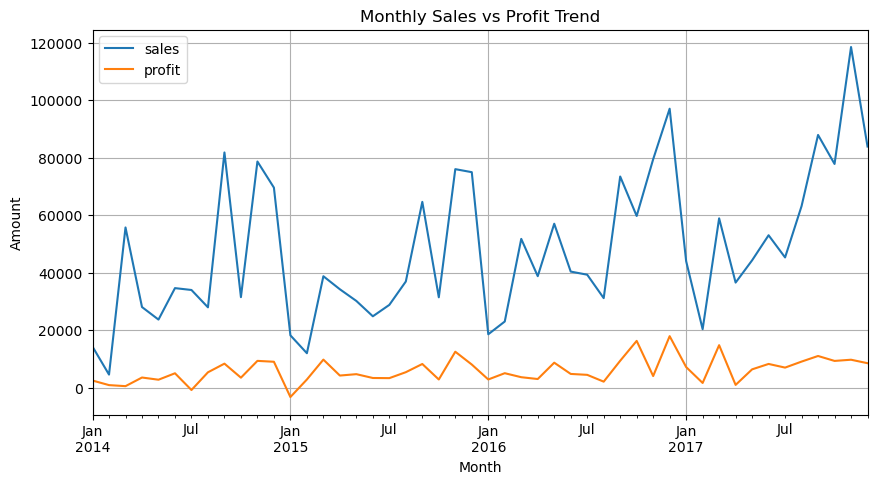

{'state_summary':                             sales      profit  profit_margin
 state                                                       
 California            457687.6315  76381.3871       0.166885
 New York              310876.2710  74038.5486       0.238161
 Texas                 170188.0458 -25729.3563      -0.151182
 Washington            138641.2700  33402.6517       0.240929
 Pennsylvania          116511.9140 -15559.9603      -0.133548
 Florida                89473.7080  -3399.3017      -0.037992
 Illinois               80166.1010 -12607.8870      -0.157272
 Ohio                   77976.7640 -16959.3178      -0.217492
 Michigan               76269.6140  24463.1876       0.320746
 Virginia               70636.7200  18597.9504       0.263290
 North Carolina         55603.1640  -7490.9122      -0.134721
 Indiana                53555.3600  18382.9363       0.343251
 Georgia                49095.8400  16250.0433       0.330986
 Kentucky               36591.7500  11199.6966       

In [47]:
run_analysis('superstore_cleaned.csv')